In [1]:
# =========================================================
# CELL 2 — Imports + Config (Ollama + gpt-oss:20b)
# =========================================================
import os
import json
import re
from typing import Any, Dict, List, Optional, Union

import pandas as pd
import matplotlib.pyplot as plt

from lida import Manager, TextGenerationConfig
from llmx import llm

OLLAMA_BASE_URL = "http://localhost:11434/v1"   # Ollama OpenAI-compatible
OLLAMA_API_KEY = "ollama"                       # any string works for Ollama
MODEL_NAME = "gpt-oss:20b-cloud"                      # your model

# Text generation defaults (close to LIDA docs)
DEFAULT_N = 1
DEFAULT_TEMP_SUMMARY = 0.2
DEFAULT_TEMP_GOALS = 0.4
DEFAULT_TEMP_VIZ = 0.2
DEFAULT_TEMP_EDIT_EVAL = 0.0
USE_CACHE = True

LIBRARY = "seaborn"  # or "seaborn"

In [2]:
# =========================================================
# CELL 3 — Data loaders (CSV/URL or JSONL logs like your lidata.log)
# =========================================================
def flatten_json(obj: Dict[str, Any], parent: str = "", sep: str = "_") -> Dict[str, Any]:
    items = {}
    for k, v in obj.items():
        new_key = f"{parent}{sep}{k}" if parent else k
        if isinstance(v, dict):
            items.update(flatten_json(v, new_key, sep=sep))
        else:
            items[new_key] = v
    return items

def load_jsonl(path: str, sample_rows: int = 5000) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= sample_rows:
                break
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            rows.append(flatten_json(obj))

    df = pd.DataFrame(rows)
    df.columns = df.columns.str.strip()
    return df

def load_csv(path_or_url: str) -> pd.DataFrame:
    return pd.read_csv(path_or_url)

In [3]:
# =========================================================
# CELL 4 — LIDA Manager using Ollama (OpenAI-compatible) WITHOUT base_url kwarg
# =========================================================
import os
from lida import Manager, TextGenerationConfig
from llmx import llm

# 1) Injecte la config dans l'environnement (ce que llmx accepte généralement)
os.environ["OPENAI_API_KEY"] = OLLAMA_API_KEY

# Selon les versions, c'est l'un de ces deux noms qui est lu.
# On met les deux pour être sûr.
os.environ["OPENAI_BASE_URL"] = OLLAMA_BASE_URL
os.environ["OPENAI_API_BASE"] = OLLAMA_BASE_URL

# 2) Crée le backend llmx sans base_url
text_gen = llm("openai")

# 3) Manager LIDA
lida = Manager(text_gen=text_gen)

from lida import TextGenerationConfig

def tg_cfg(model: str, temperature: float = 0.2, n: int = 1, use_cache: bool = False):
    return TextGenerationConfig(n=n, temperature=temperature, model=model, use_cache=use_cache)

print("LIDA manager ready via Ollama:", OLLAMA_BASE_URL, "model:", MODEL_NAME)

LIDA manager ready via Ollama: http://localhost:11434/v1 model: gpt-oss:20b-cloud


In [4]:
# =========================================================
# CELL 5 — Load your data
# Choose ONE:
#   A) JSONL logs (your case): data/lidata.log
#   B) CSV/URL (LIDA demo)
# =========================================================

# --- A) Your JSONL logs
DATA_JSONL = "data/lidata.log"
df = load_jsonl(DATA_JSONL, sample_rows=5000)
data = df  # LIDA can summarize a DataFrame directly
print("Loaded JSONL DataFrame:", df.shape)
print(df.columns[:20])

# --- B) LIDA demo (uncomment to test)
# data = "https://raw.githubusercontent.com/uwdata/draco/master/data/cars.csv"
# print("Using CSV URL:", data)

Loaded JSONL DataFrame: (5, 105)
Index(['DamageState', 'EntityIdentifier', 'EntityType', 'ForceIdentifier',
       'HasAmmunitionSupplyCap', 'HasFuelSupplyCap', 'HasRecoveryCap',
       'HasRepairCap', 'HlaFrameType', 'HlaInstanceName', 'HlaObjectType',
       'Immobilized', 'IsConcealed', 'Marking', 'SimTime',
       'Spatial_FPB_IsFrozen', 'Spatial_FPB_Orientation_phi',
       'Spatial_FPB_Orientation_psi', 'Spatial_FPB_Orientation_theta',
       'Spatial_FPB_VelocityVector_x'],
      dtype='object')


In [5]:
# =========================================================
# CELL 5.5 — Clean nested columns (lists/dicts) for LIDA summarize
# =========================================================
import json
import pandas as pd

def sanitize_for_lida(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # détecte les colonnes qui contiennent des listes/dicts dans un échantillon
    bad_cols = []
    for c in out.columns:
        s = out[c].dropna()
        if s.empty:
            continue
        sample = s.head(50)
        if sample.apply(lambda v: isinstance(v, (list, dict))).any():
            bad_cols.append(c)

    if bad_cols:
        print("[sanitize] Converting nested columns to JSON strings:", bad_cols)

    for c in bad_cols:
        out[c] = out[c].apply(lambda v: json.dumps(v, ensure_ascii=False) if isinstance(v, (list, dict)) else v)

    return out

# applique uniquement si data est un DataFrame
if isinstance(data, pd.DataFrame):
    df = sanitize_for_lida(df)
    data = df
    print("Sanitized df shape:", df.shape)

[sanitize] Converting nested columns to JSON strings: ['contacts', 'sensors', 'weapons']
Sanitized df shape: (5, 105)


In [6]:
# =========================================================
# CELL 6 — Summarize (like LIDA docs)
# summary_method="default" is deterministic stats.
# summary_method="llm" enriches with the model (slower, often better).
# =========================================================
summary_method = "default"  # try "llm" later if you want

summary = lida.summarize(
    data,
    summary_method=summary_method,
    textgen_config=tg_cfg(model=MODEL_NAME,    temperature=DEFAULT_TEMP_SUMMARY, use_cache=USE_CACHE)
)

summary

{'name': '',
 'file_name': '',
 'dataset_description': '',
 'fields': [{'column': 'DamageState',
   'properties': {'dtype': 'category',
    'samples': ['damaged', 'no damage'],
    'num_unique_values': 2,
    'semantic_type': '',
    'description': ''}},
  {'column': 'EntityIdentifier',
   'properties': {'dtype': 'string',
    'samples': ['VRF262162:1', 'VRF262162:172'],
    'num_unique_values': 4,
    'semantic_type': '',
    'description': ''}},
  {'column': 'EntityType',
   'properties': {'dtype': 'category',
    'samples': ['1:1:71:2:5:0:1', '1:1:222:1:12:0:0'],
    'num_unique_values': 2,
    'semantic_type': '',
    'description': ''}},
  {'column': 'ForceIdentifier',
   'properties': {'dtype': 'int64',
    'samples': [1, 2],
    'num_unique_values': 2,
    'semantic_type': '',
    'description': ''}},
  {'column': 'HasAmmunitionSupplyCap',
   'properties': {'dtype': 'boolean',
    'samples': [False, True],
    'num_unique_values': 2,
    'semantic_type': '',
    'description': '

In [7]:
import json
import numpy as np
import pandas as pd

def deep_sanitize(obj):
    # numpy
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating, np.bool_)):
        return obj.item()

    # pandas
    if isinstance(obj, (pd.Series, pd.Index)):
        return obj.tolist()
    if isinstance(obj, pd.DataFrame):
        # on évite de sérialiser un DF complet dans le summary (trop gros)
        return obj.head(50).to_dict(orient="list")

    # python containers
    if isinstance(obj, dict):
        # clés en str pour éviter les clés bizarres
        return {str(k): deep_sanitize(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [deep_sanitize(v) for v in obj]

    # fallback
    return obj

def find_ndarrays(obj, path="root", max_hits=30, hits=None):
    if hits is None:
        hits = []
    if len(hits) >= max_hits:
        return hits

    if isinstance(obj, np.ndarray):
        hits.append(path)
        return hits

    if isinstance(obj, dict):
        for k, v in obj.items():
            find_ndarrays(v, f"{path}.{k}", max_hits=max_hits, hits=hits)
    elif isinstance(obj, (list, tuple, set)):
        for i, v in enumerate(obj):
            find_ndarrays(v, f"{path}[{i}]", max_hits=max_hits, hits=hits)

    return hits

summary_clean = deep_sanitize(summary)

# Vérifie qu'il ne reste plus de ndarray
hits = find_ndarrays(summary_clean)
print("ndarray hits in summary_clean:", hits[:10], "count=", len(hits))

# BONUS: fabrique aussi une version string (hashable)
summary_json = json.dumps(summary_clean, ensure_ascii=False)
print("summary_json length:", len(summary_json))

ndarray hits in summary_clean: [] count= 0
summary_json length: 24370


In [8]:
#6.6
import json
import numpy as np
import pandas as pd

JSON_PRIMITIVES = (str, int, float, bool, type(None))

def deep_json_only(obj):
    # numpy
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating, np.bool_)):
        return obj.item()

    # pandas
    if isinstance(obj, (pd.Series, pd.Index)):
        return obj.tolist()
    if isinstance(obj, pd.DataFrame):
        return obj.head(50).to_dict(orient="list")

    # python primitives
    if isinstance(obj, JSON_PRIMITIVES):
        return obj

    # containers
    if isinstance(obj, dict):
        return {str(k): deep_json_only(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [deep_json_only(v) for v in obj]

    # TOUT le reste -> string (clé pour éviter des objets cachés)
    return str(obj)

summary_json_only = deep_json_only(summary)

# Check hard: must be JSON serializable
summary_json_strict = json.dumps(summary_json_only, ensure_ascii=False)
print("OK: strict JSON summary length =", len(summary_json_strict))

OK: strict JSON summary length = 24370


In [9]:
import requests, json, re

def call_ollama_chat_json(model: str, system: str, user: str, temperature: float = 0.0) -> str:
    r = requests.post("http://localhost:11434/v1/chat/completions", json={
        "model": model,
        "messages": [
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
        "temperature": temperature
    })
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def extract_json_object(s: str) -> Any:
    # enlève ```json ... ```
    s = re.sub(r"^```(?:json)?", "", s.strip(), flags=re.IGNORECASE).strip()
    s = re.sub(r"```$", "", s.strip()).strip()
    # prend le premier bloc JSON (array ou objet)
    m = re.search(r"(\[.*\]|\{.*\})", s, flags=re.DOTALL)
    if not m:
        raise ValueError("No JSON found in model output.")
    return json.loads(m.group(1))

def safe_goals(summary: Any, n: int = 3, model: str = "gpt-oss:20b-cloud") -> List[Dict[str, Any]]:
    system = (
        "You generate visualization goals. Return ONLY valid JSON. "
        "No prose, no markdown, no backticks."
    )
    user = f"""
Given this dataset summary, return a JSON array of {n} goals.
Each goal must be an object with:
- "question": string
- "visualization": string (e.g., 'bar chart of X by Y', 'scatter of A vs B', 'line of Y over time X', 'histogram of X')
- "rationale": string

Return ONLY the JSON array.

SUMMARY:
{summary}
""".strip()

    txt = call_ollama_chat_json(model=model, system=system, user=user, temperature=0.0)
    goals = extract_json_object(txt)
    if not isinstance(goals, list):
        raise ValueError("Expected a JSON array of goals.")
    return goals

In [10]:
goals = safe_goals(summary, n=3, model=MODEL_NAME)
for i, g in enumerate(goals):
    print("\n--- Goal", i, "---")
    print(g["question"])
    print("Viz:", g["visualization"])
    print("Why:", g["rationale"])


--- Goal 0 ---
What proportion of entities are damaged versus undamaged per Marking label?
Viz: bar chart of DamageState count by Marking
Why: Provides insight into damage distribution across entity classes and helps prioritize maintenance or support.

--- Goal 1 ---
How does the vertical position (z-coordinate) of entities change throughout the simulation?
Viz: line of Spatial_FPB_WorldLocation_z over SimTime
Why: Tracks altitude changes to detect motion patterns or potential collision risks during the simulation.

--- Goal 2 ---
What is the distribution of the orientation angle (phi) for FPB spatial entities?
Viz: histogram of Spatial_FPB_Orientation_phi
Why: Helps assess whether orientations are random or clustered, indicating movement or formation patterns.


In [11]:
import builtins
import matplotlib.pyplot as plt

def _plot(*args, **kwargs):
    return plt.plot(*args, **kwargs)

builtins.plot = _plot
print("patched: builtins.plot is defined")

patched: builtins.plot is defined


In [15]:
import difflib

print("Has DamageState:", "DamageState" in df.columns)
print("Has ForceIdentifier:", "ForceIdentifier" in df.columns)

print("Closest to DamageState:", difflib.get_close_matches("DamageState", df.columns, n=10))
print("Closest to ForceIdentifier:", difflib.get_close_matches("ForceIdentifier", df.columns, n=10))

Has DamageState: True
Has ForceIdentifier: True
Closest to DamageState: ['DamageState']
Closest to ForceIdentifier: ['ForceIdentifier', 'EntityIdentifier']



****
 unhashable type: 'numpy.ndarray'
Nb charts: 0


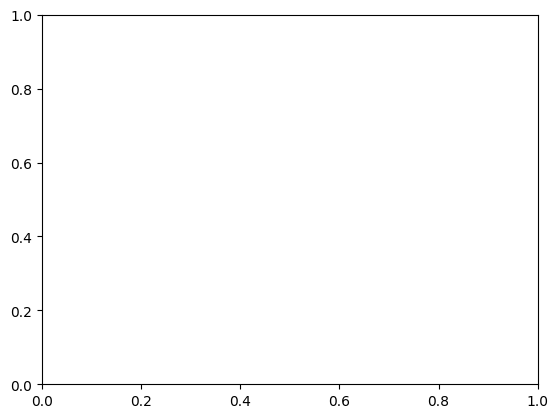

In [17]:
goal_query = "bar chart of count by ForceIdentifier"
charts = lida.visualize(
    summary=summary_json_only,
    goal=goal_query,
    library="seaborn",
    textgen_config=tg_cfg(model=MODEL_NAME, temperature=0.0, use_cache=False)
)
print("Nb charts:", len(charts))

In [18]:
df.columns[:50]

Index(['DamageState', 'EntityIdentifier', 'EntityType', 'ForceIdentifier',
       'HasAmmunitionSupplyCap', 'HasFuelSupplyCap', 'HasRecoveryCap',
       'HasRepairCap', 'HlaFrameType', 'HlaInstanceName', 'HlaObjectType',
       'Immobilized', 'IsConcealed', 'Marking', 'SimTime',
       'Spatial_FPB_IsFrozen', 'Spatial_FPB_Orientation_phi',
       'Spatial_FPB_Orientation_psi', 'Spatial_FPB_Orientation_theta',
       'Spatial_FPB_VelocityVector_x', 'Spatial_FPB_VelocityVector_y',
       'Spatial_FPB_VelocityVector_z', 'Spatial_FPB_WorldLocation_x',
       'Spatial_FPB_WorldLocation_y', 'Spatial_FPB_WorldLocation_z',
       'Spatial_FPW_IsFrozen', 'Spatial_FPW_Orientation_phi',
       'Spatial_FPW_Orientation_psi', 'Spatial_FPW_Orientation_theta',
       'Spatial_FPW_VelocityVector_x', 'Spatial_FPW_VelocityVector_y',
       'Spatial_FPW_VelocityVector_z', 'Spatial_FPW_WorldLocation_x',
       'Spatial_FPW_WorldLocation_y', 'Spatial_FPW_WorldLocation_z',
       'Spatial_FVB_IsFrozen', 'Sp


****
 unhashable type: 'numpy.ndarray'
Nb charts: 0

****
 unhashable type: 'numpy.ndarray'
Nb charts: 0

[ERROR] LIDA returned 0 charts. This usually means an internal error occurred but was swallowed.
Try the traceback version below if you still see nothing.


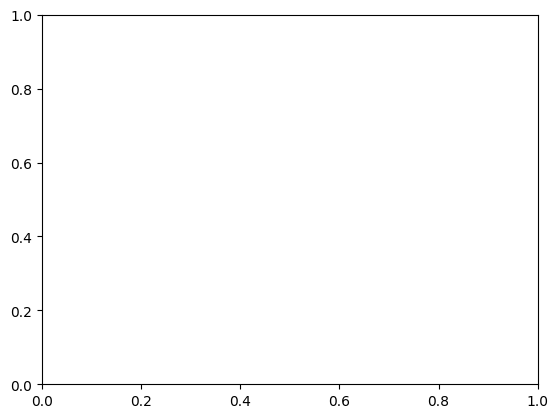

In [12]:
import traceback
from lida.utils import plot_raster

goal_query = "bar chart of DamageState counts grouped by ForceIdentifier"
charts = lida.visualize(
    summary=summary_clean,
    goal=goal_query,
    library="seaborn",
    textgen_config=tg_cfg(model=MODEL_NAME, temperature=0.0, use_cache=False)
)
print("Nb charts:", len(charts))

try:
    charts = lida.visualize(
        summary=summary,
        goal=goal_query,
        library="seaborn",
        textgen_config=tg_cfg(model=MODEL_NAME, temperature=0.0, use_cache=False)
    )
    print("Nb charts:", len(charts))

    if len(charts) == 0:
        print("\n[ERROR] LIDA returned 0 charts. This usually means an internal error occurred but was swallowed.")
        print("Try the traceback version below if you still see nothing.")

    else:
        c0 = charts[0]
        code = getattr(c0, "code", None) or (c0.get("code") if isinstance(c0, dict) else None)
        raster = getattr(c0, "raster", None) or (c0.get("raster") if isinstance(c0, dict) else None)

        print("\nHas code:", bool(code))
        print("Has raster:", raster is not None)

        if code:
            print("\n--- GENERATED CODE (first 2500 chars) ---\n")
            print(code[:2500])

        if raster is not None:
            plot_raster([raster])
        else:
            print("\n[info] No raster. If you have code above, run the exec cell to render it.")

except Exception:
    traceback.print_exc()


****
 unhashable type: 'numpy.ndarray'
Nb charts: 0

****
 unhashable type: 'numpy.ndarray'
Nb charts: 0

[ERROR] LIDA returned 0 charts. This usually means an internal error occurred but was swallowed.
Try the traceback version below if you still see nothing.


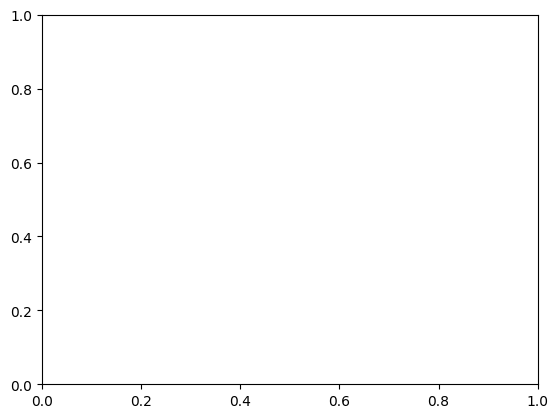

In [ ]:
import traceback
from lida.utils import plot_raster

goal_query = "bar chart of DamageState counts grouped by ForceIdentifier"
charts = lida.visualize(
    summary=summary_clean,
    goal=goal_query,
    library="seaborn",
    textgen_config=tg_cfg(model=MODEL_NAME, temperature=0.0, use_cache=False)
)
print("Nb charts:", len(charts))

try:
    charts = lida.visualize(
        summary=summary,
        goal=goal_query,
        library="seaborn",
        textgen_config=tg_cfg(model=MODEL_NAME, temperature=0.0, use_cache=False)
    )
    print("Nb charts:", len(charts))

    if len(charts) == 0:
        print("\n[ERROR] LIDA returned 0 charts. This usually means an internal error occurred but was swallowed.")
        print("Try the traceback version below if you still see nothing.")

    else:
        c0 = charts[0]
        code = getattr(c0, "code", None) or (c0.get("code") if isinstance(c0, dict) else None)
        raster = getattr(c0, "raster", None) or (c0.get("raster") if isinstance(c0, dict) else None)

        print("\nHas code:", bool(code))
        print("Has raster:", raster is not None)

        if code:
            print("\n--- GENERATED CODE (first 2500 chars) ---\n")
            print(code[:2500])

        if raster is not None:
            plot_raster([raster])
        else:
            print("\n[info] No raster. If you have code above, run the exec cell to render it.")

except Exception:
    traceback.print_exc()

In [14]:
cars = "https://raw.githubusercontent.com/uwdata/draco/master/data/cars.csv"
summary_cars = lida.summarize(cars, summary_method="default", textgen_config=tg_cfg(model=MODEL_NAME, temperature=0.2, use_cache=False))
charts_cars = lida.visualize(summary=summary_cars, goal="bar chart of count by Type", library="seaborn",
                             textgen_config=tg_cfg(model=MODEL_NAME, temperature=0.0, use_cache=False))
print("cars charts:", len(charts_cars))

<string>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



cars charts: 1


STDOUT:
 
****
 unhashable type: 'numpy.ndarray'

STDERR:
 
Nb charts: 0


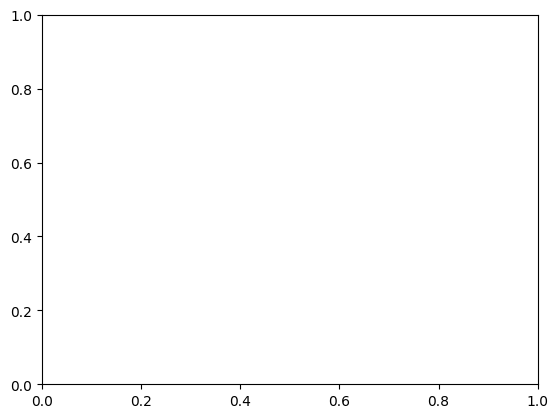

In [65]:
import io, contextlib, traceback

buf_out = io.StringIO()
buf_err = io.StringIO()

goal_query = "bar chart of DamageState counts grouped by ForceIdentifier"

with contextlib.redirect_stdout(buf_out), contextlib.redirect_stderr(buf_err):
    try:
        charts = lida.visualize(
            summary=summary_clean,
            goal=goal_query,
            library="seaborn",
            textgen_config=tg_cfg(model=MODEL_NAME, temperature=0.0, use_cache=False)
        )
    except Exception:
        traceback.print_exc()

print("STDOUT:\n", buf_out.getvalue()[:4000])
print("STDERR:\n", buf_err.getvalue()[:4000])
print("Nb charts:", len(charts) if "charts" in locals() else "charts not set")

In [25]:
import re

def pick_column_candidates(profile: dict, max_each: int = 20):
    # profile[col] = {"dtype": "...", "nunique": ..., "examples": [...], ...}
    cat, num, time = [], [], []

    def looks_like_time(col, meta):
        c = col.lower()
        if "time" in c or "date" in c or "timestamp" in c:
            return True
        # exemples qui ressemblent à date/iso
        ex = meta.get("examples", [])
        if not ex:
            return False
        s = " ".join(ex[:3])
        return bool(re.search(r"\d{4}-\d{2}-\d{2}|\d{2}:\d{2}:\d{2}", s))

    for col, meta in profile.items():
        dtype = (meta.get("dtype") or "").lower()
        nunique = meta.get("nunique", 0)
        miss = meta.get("missing_ratio", 0.0)

        # skip colonnes trop vides
        if miss is not None and miss > 0.95:
            continue

        # time candidates
        if looks_like_time(col, meta):
            time.append(col)
            continue

        # numeric candidates: on se base sur présence de min/max/mean ajoutés dans quick_profile()
        if "min" in meta and "max" in meta:
            num.append(col)
            continue

        # categorical candidates: peu de uniques
        if nunique and nunique <= 100:
            cat.append(col)

    return cat[:max_each], num[:max_each], time[:max_each]

In [19]:
import pandas as pd

def quick_profile(df: pd.DataFrame, max_cols: int = 40):
    # top colonnes utiles: catégorielles + numériques
    cols = list(df.columns)
    cols = cols[:max_cols]

    profile = {}
    for c in cols:
        s = df[c]
        profile[c] = {
            "dtype": str(s.dtype),
            "missing_ratio": float(s.isna().mean()),
            "nunique": int(s.nunique(dropna=True)),
        }
        # exemples de valeurs
        ex = s.dropna().astype(str).head(5).tolist()
        profile[c]["examples"] = ex

        # stats num
        sn = pd.to_numeric(s, errors="coerce")
        if sn.notna().sum() > 0:
            profile[c]["min"] = float(sn.min())
            profile[c]["max"] = float(sn.max())
            profile[c]["mean"] = float(sn.mean())

    return profile

profile = quick_profile(df, max_cols=50)  # tu peux baisser si c'est trop long
print("profile keys:", list(profile.keys())[:10])

profile keys: ['DamageState', 'EntityIdentifier', 'EntityType', 'ForceIdentifier', 'HasAmmunitionSupplyCap', 'HasFuelSupplyCap', 'HasRecoveryCap', 'HasRepairCap', 'HlaFrameType', 'HlaInstanceName']


In [26]:
import requests, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import traceback

def ollama_chat(model: str, system: str, user: str, temperature: float = 0.0) -> str:
    r = requests.post("http://localhost:11434/v1/chat/completions", json={
        "model": model,
        "messages": [
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
        "temperature": temperature,
    })
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def extract_python_code(txt: str) -> str:
    m = re.search(r"```python(.*?)```", txt, flags=re.DOTALL | re.IGNORECASE)
    if m:
        return m.group(1).strip()
    m = re.search(r"```(.*?)```", txt, flags=re.DOTALL)
    if m:
        return m.group(1).strip()
    return txt.strip()

def strip_import_lines(code: str) -> str:
    # enlève les lignes "import ..." et "from ... import ..."
    lines = []
    for line in code.splitlines():
        if re.match(r"^\s*(import|from)\s+\w+", line):
            continue
        lines.append(line)
    return "\n".join(lines)

SYSTEM = """You are a data visualization code generator.
Return ONLY Python code (no explanations, no markdown, no backticks).
DO NOT write any import statements.
Use pandas DataFrame `df` already loaded.
Use seaborn as sns and matplotlib.pyplot as plt (already available).
Always call plt.tight_layout() and end with plt.show().

Rules:
- If user asks for count by category -> use groupby().size() or value_counts().
- For distribution of categories -> use seaborn countplot.
- For relationship between two numeric -> seaborn scatterplot.
- For trend over time -> lineplot and sort by x first.
"""

def generate_and_run_viz(question: str, model: str):
    cat_cols, num_cols, time_cols = pick_column_candidates(profile, max_each=25)

    user = f"""
    DATA PROFILE (schema + examples):
    {profile}

    CANDIDATE COLUMNS (auto-detected):
    - categorical_cols: {cat_cols}
    - numeric_cols: {num_cols}
    - time_cols: {time_cols}

    USER QUESTION:
    {question}

    Rules:
    - Use ONLY existing columns from the profile keys.
    - If the question implies a time trend, choose x from time_cols (or a numeric time-like column) and y from numeric_cols.
    - If the question implies a distribution of categories, choose x from categorical_cols.
    - If the question implies grouping ("by", "par"), choose group_by from categorical_cols and aggregate a numeric column if asked (mean/sum/min/max), otherwise count.
    - Produce a single clear chart.
    """.strip()
    
    raw = ollama_chat(model=model, system=SYSTEM, user=user, temperature=0.0)
    code = extract_python_code(raw)
    code = strip_import_lines(code)  # sécurité si le modèle met quand même des imports

    print("=== GENERATED CODE (first 1500 chars) ===")
    print(code[:1500])
    print("========================================")

    # Exec "semi-safe": autorise quelques builtins nécessaires
    safe_builtins = {
        "len": len, "range": range, "min": min, "max": max, "sum": sum,
        "print": print, "sorted": sorted, "list": list, "dict": dict, "set": set,
        "enumerate": enumerate, "zip": zip, "abs": abs
    }
    safe_globals = {
        "__builtins__": safe_builtins,
        "pd": pd, "sns": sns, "plt": plt, "df": df
    }

    try:
        exec(code, safe_globals, {})
    except Exception:
        print("\n=== EXEC ERROR TRACEBACK ===")
        traceback.print_exc()
        print("=== END TRACEBACK ===")


=== GENERATED CODE (first 1500 chars) ===
fig, ax = plt.subplots(figsize=(8,6))
grouped = df.groupby(['ForceIdentifier', 'DamageState']).size().reset_index(name='count')
sns.barplot(data=grouped, x='ForceIdentifier', y='count', hue='DamageState', ax=ax)
ax.set_title('Dégats groupés par identifiant de forces')
ax.set_xlabel('Identifiant de force')
ax.set_ylabel('Nombre de rapports')
plt.tight_layout()
plt.show()


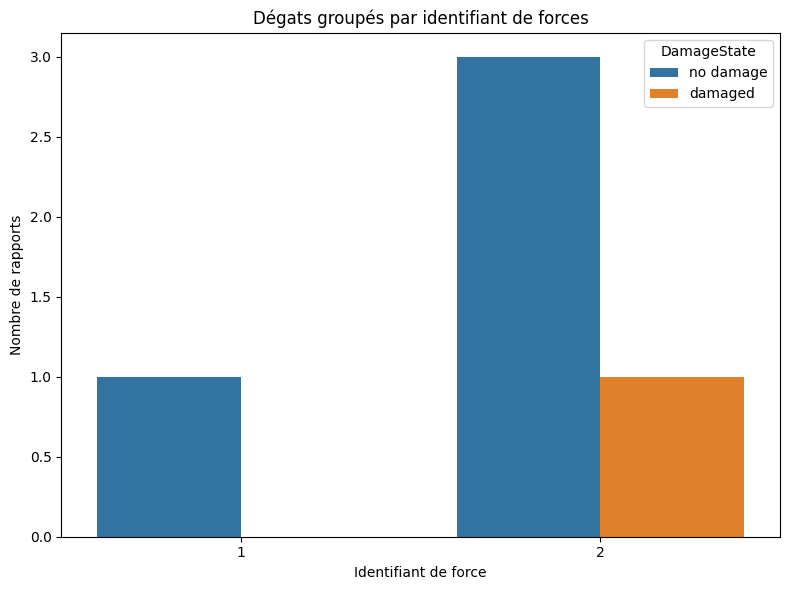

In [27]:

# Test
generate_and_run_viz(
    " Dégats groupé par identifiant de forces ",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
sns.countplot(x='EntityType', data=df)
plt.title('Nombre d’entités par type d\'entités')
plt.xlabel('Type d’entité')
plt.ylabel('Nombre d’entités')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


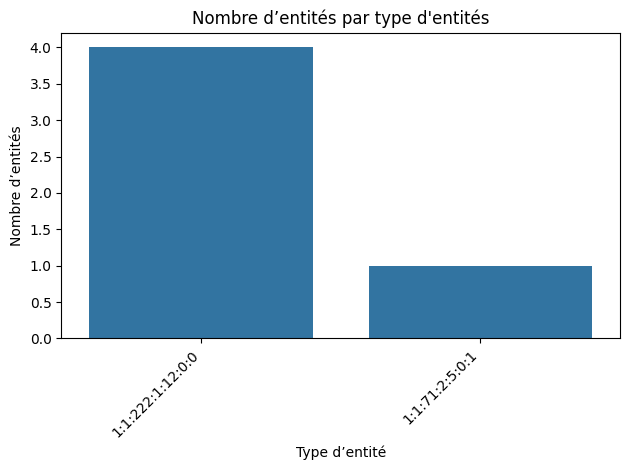

In [29]:
generate_and_run_viz(
    "Nombre d’entités par type d'entités",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='HasAmmunitionSupplyCap', order=[False, True])
plt.title('Entities without ammunition')
plt.xlabel('Has Ammunition Supply Cap')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


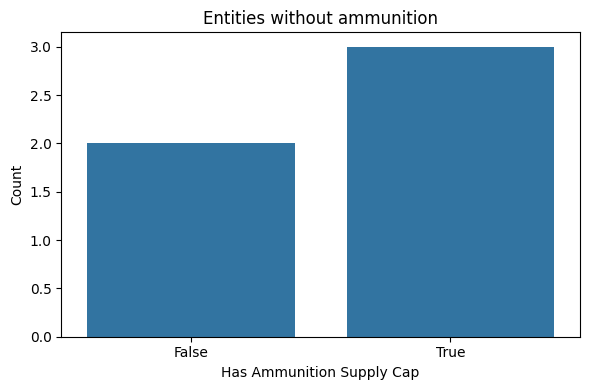

In [30]:
generate_and_run_viz(
    "Nombre d’entités qui n'ont pas de munitions",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
sns.scatterplot(x='Spatial_FPB_WorldLocation_x', y='Spatial_FPB_WorldLocation_y', data=df)
plt.xlabel('Spatial_FPB_WorldLocation_x')
plt.ylabel('Spatial_FPB_WorldLocation_y')
plt.title('Scatter plot of Fpb positions (x vs y)')
plt.tight_layout()
plt.show()


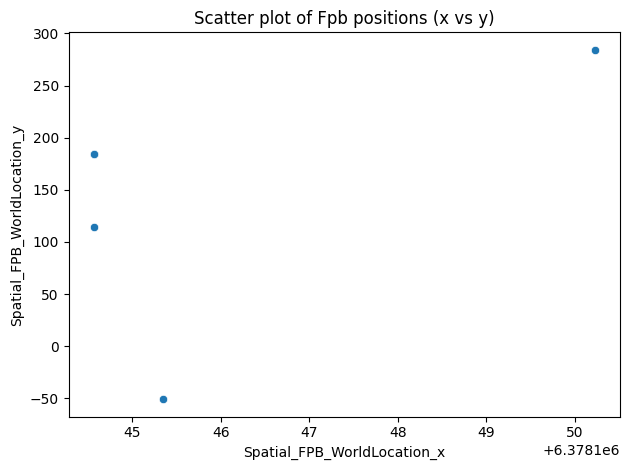

In [31]:
generate_and_run_viz(
    "Nuage de points des positions fpb x et fpb y",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
# Top 20 most frequent entities by EntityIdentifier
top_entities = df['EntityIdentifier'].value_counts().nlargest(20).reset_index()
top_entities.columns = ['EntityIdentifier', 'Count']

plt.figure(figsize=(10,6))
sns.barplot(x='EntityIdentifier', y='Count', data=top_entities, palette='viridis')
plt.title('Top 20 Most Frequent Entities')
plt.xlabel('EntityIdentifier')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<string>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



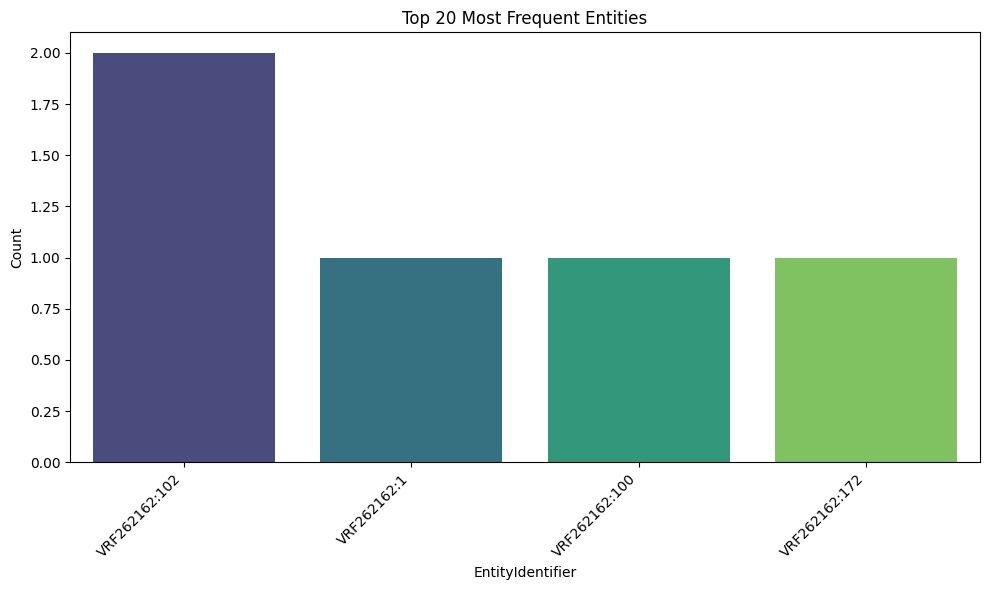

In [32]:
generate_and_run_viz(
    "Top 20 des entitésles plus fréquents",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
plt.figure(figsize=(10,6))
sns.lineplot(data=df.sort_values('SimTime'), x='SimTime', y='Spatial_FPB_Orientation_phi')
plt.title('Evolution de Spatial_FPB_Orientation_phi dans le temps')
plt.xlabel('SimTime')
plt.ylabel('Spatial_FPB_Orientation_phi')
plt.tight_layout()
plt.show()


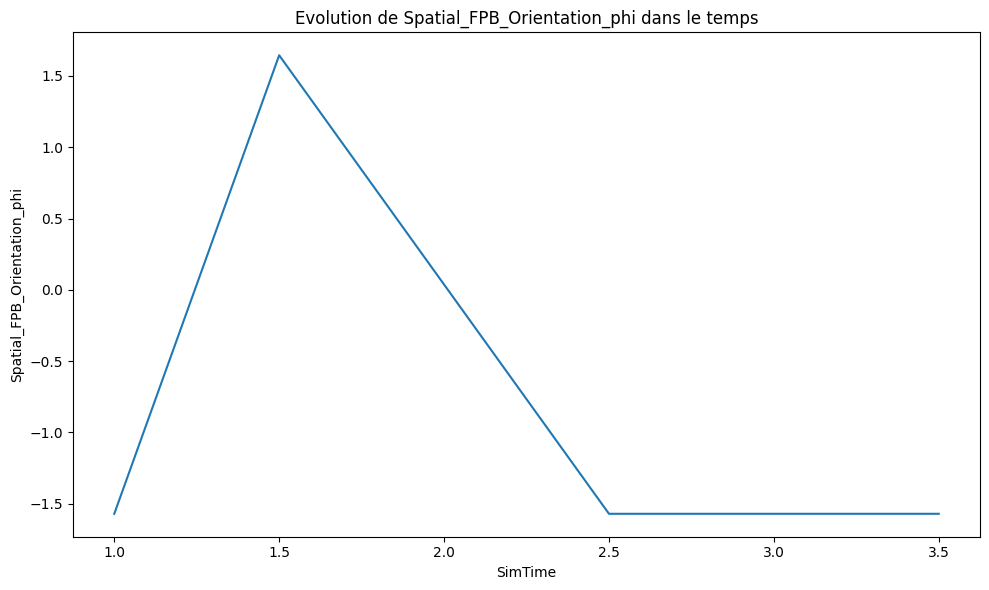

In [34]:
generate_and_run_viz(
    "TEvolution de FPB phi au cours du temps",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
sns.histplot(df['SimTime'], bins=10, kde=False)
plt.title('Histogramme du temps')
plt.xlabel('SimTime')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


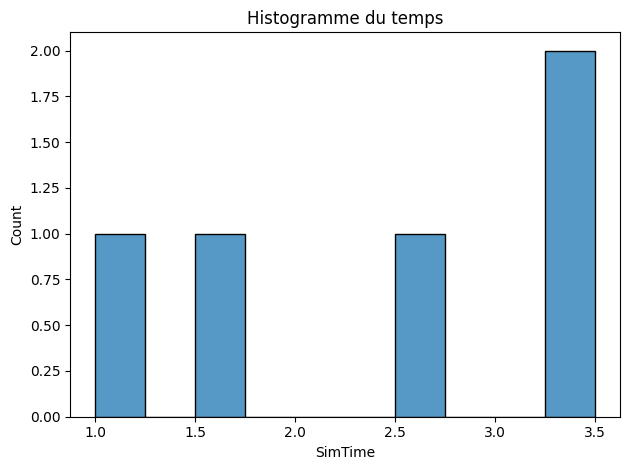

In [37]:
generate_and_run_viz(
    "Histogramme du temps",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
df_avg = df.groupby('ForceIdentifier')['Spatial_FPB_Orientation_phi'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='ForceIdentifier', y='Spatial_FPB_Orientation_phi', data=df_avg, palette='viridis')
plt.xlabel('Force Identifier')
plt.ylabel('Average FPB Phi')
plt.title('Moyenne du FPB Phi par Identifiant de Force')
plt.tight_layout()
plt.show()


<string>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



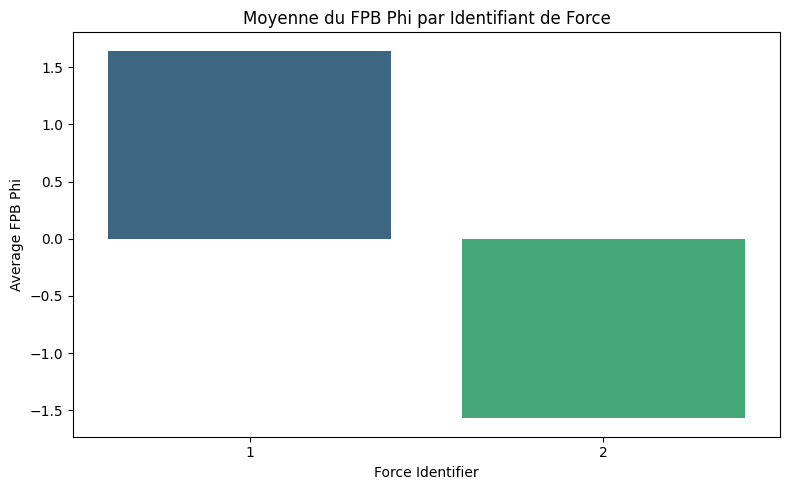

In [43]:
generate_and_run_viz(
    "Moyenne des fpb phi par identifiant de force",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
sns.countplot(x='ForceIdentifier', data=df)
plt.title("Répartition par camp")
plt.xlabel("ForceIdentifier")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


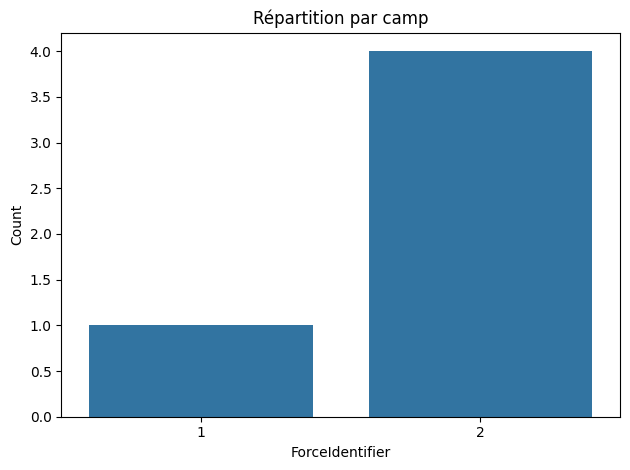

In [41]:
generate_and_run_viz(
    "Répartition par camp",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
median_df = df.groupby('EntityType')['SimTime'].median().reset_index().sort_values('SimTime')
sns.barplot(data=median_df, x='EntityType', y='SimTime', palette='Blues_d')
plt.xlabel('Type d\'entité')
plt.ylabel('Médiane du temps (SimTime)')
plt.title('Médiane du temps par type d\'entité')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<string>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



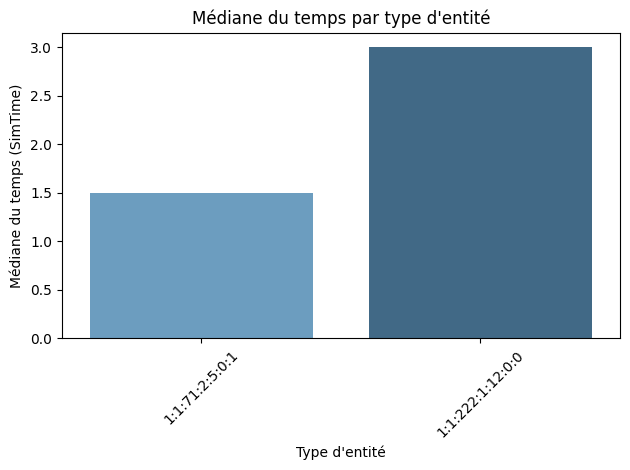

In [42]:
generate_and_run_viz(
    "Médiane du temps de chaque type d'entité",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
agg = df.groupby('ForceIdentifier')['Spatial_FPB_WorldLocation_y'].max().reset_index()
sns.barplot(x='ForceIdentifier', y='Spatial_FPB_WorldLocation_y', data=agg, palette='viridis')
plt.title('Maximum FPB Y coordinate per Force ID')
plt.xlabel('Force Identifier')
plt.ylabel('Max FPB Y')
plt.tight_layout()
plt.show()


<string>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



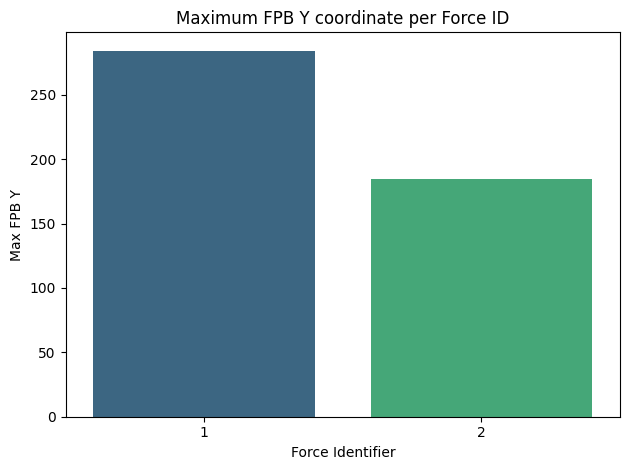

In [45]:
generate_and_run_viz(
    "Maximum de fpb y par id des forces",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
counts = df.groupby('ForceIdentifier')['EntityIdentifier'].nunique().reset_index(name='unique_entities')
plt.figure(figsize=(8,6))
sns.barplot(data=counts, x='ForceIdentifier', y='unique_entities', color='magenta')
plt.title('Nombre de valeurs uniques d\'entités par force')
plt.xlabel('ForceIdentifier')
plt.ylabel('Nombre d\'entités uniques')
plt.tight_layout()
plt.show()


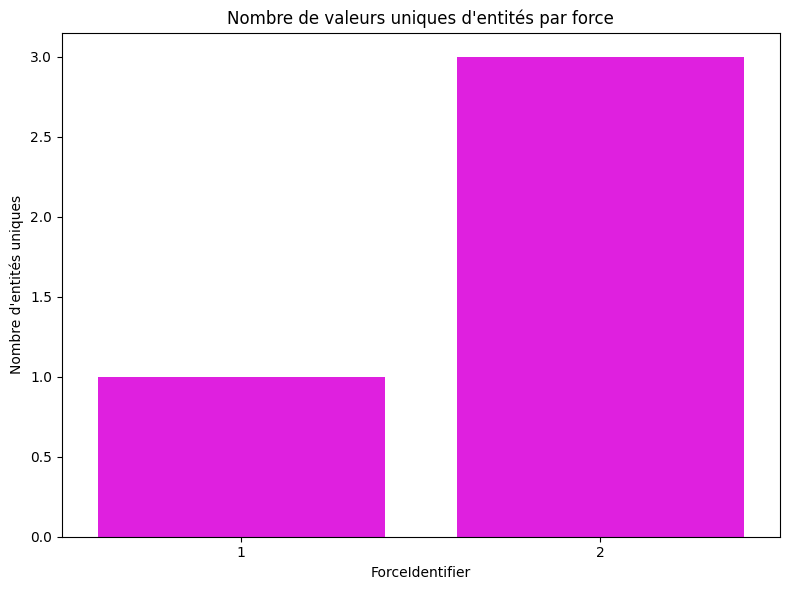

In [48]:
generate_and_run_viz(
    "Nombre de valeurs uniques de d'entités par force avec des courbes de teinte rose",
    model=MODEL_NAME
)

